# **Loan approval Prediction**


Loan approval is an important process that helps financial institutions evaluate whether an applicant is capable of making a reliable repayment commitment. By assessing factors such as income, credit history, and financial background, loan approval systems help reduce the risk of unsuitable lending decisions.

This project will focus on finding an efficient Machine Learning model to help us predict if a user can be approved to take a loan for a house. We will focus on three main models and compare them together. The models will be Logistic Regression, Decision tree and random forest.

Exploratory Data Analysis (EDA) will be performed to gain more knowledge on the features included in our dataset and their relationships together. Next, some feature engineering and preprocessing techniques will be applied before training our models and comparing them to find the best performing model amongst the ones that were chosen for this project. 


## Libraries

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

## Loading and understanding the data

In this section we will investigate our columns/features at a basic level to gain some information on our dataset. Metrics such as Shape, duplicates, Unique values in Categorical and etc will be looked at.

In [18]:
df = pd.read_csv('../data/loan_approval_dataset.csv')

In [19]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [20]:
print(f"number of rows: {df.shape[0]} \nnumber of columns: {df.shape[1]}")

number of rows: 4269 
number of columns: 13


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


The dataset consists of 4269 rows and 13 columns. The target variable is **loan_status which** has **Approved** and **Rejected** to show the status. A breif discription of all the columns can be found below.

**featuers:**

| Feature | Description | Data Type |
|---------|-------------|-----------|
|loan_id|unique Id for each loan|Numerical|
|no_of_dependents|Level of education of the applicant|Numerical|
|education|Level of education of the applicant|Categorical|
|self_employed|Showing if the applicant is self employed or not|Binary (Yes, No)|
|income_annum|Anual income of the applicant|Numerical|
|loan_amount|The amount of loan the applicant has taken|Numerical|
|loan_term|The term of the loan in years|Numerical|
|cibil_score|The credit score of the applicant|Numerical|
|residential_assets_value|The value of the applicants residential assets|Numerical|
|commercial_assets_value|The value of the applicants commercial assets|Numerical|
|luxury_assets_value|The value of the applicants luxury assets|Numerical|
|bank_asset_value|The value of the applicants bank assets|Numerical|
|loan_status|Showing the status of the loan (**Target Variable**)|Binary (Approved, Rejected)|

A small problem was found with the column name, almost all of them have an extra empty space in the beginning.

In [22]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


Let's have a look at all of the unique values that our categorical features have, and statistical summary of our numerical features and check for duplicates and null values.

In [23]:
print(f"education: {df[" education"].unique().tolist()}")
print(f"self_employed: {df[" self_employed"].unique().tolist()}")
print(f"loan_status: {df[" loan_status"].unique().tolist()}")

education: [' Graduate', ' Not Graduate']
self_employed: [' No', ' Yes']
loan_status: [' Approved', ' Rejected']


In [24]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

The categorical features were find to have a minor  formatting inconsistencies due to leading whitespace, similar to the issue found in column names. The statistical summary does not bring any concern; However, it has been reaveld that they are on differnet scales and scalling is needed before training our Logestic Regression model. Moreover, the dataset contains no duplicate or missing record.

## Data cleaning

in the previous section, it was found that column names and values in the categorical features had a leading whitspace issue. To resolve we will take care of this problem in this section by removing them.

In [27]:
df.columns = df.columns.str.strip()


In [28]:
print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [29]:
df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()

In [30]:
print(f"education: {df["education"].unique().tolist()}")
print(f"self_employed: {df["self_employed"].unique().tolist()}")
print(f"loan_status: {df["loan_status"].unique().tolist()}")

education: ['Graduate', 'Not Graduate']
self_employed: ['No', 'Yes']
loan_status: ['Approved', 'Rejected']


As seen above the leading whitesapce issue has been resolved.

## Exploratory Data Analysis (EDA)

In this section we will exploratory data analysis will be conducted investigate feature and target variables by plotting charts to better understand the dataset and find hidden patternres and gain insight into relationship between variables. The analysis will include a feature analysis by investigating individual feature distributions and relationships between features, a target analysis by checking the distribution of the target variable and feature-to-target relationships, and a correlation heatmap to examine the relationships among the numerical features.

In [32]:
# setting the style
sns.set_style("whitegrid")

### feature Analysis

#### Individual feature distributions

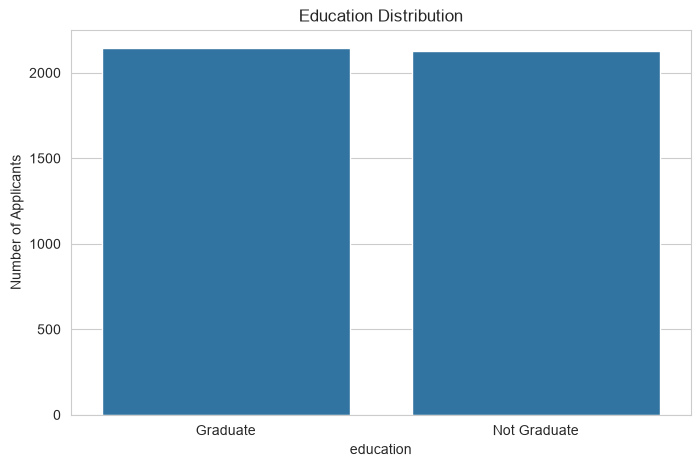

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="education")

plt.ylabel("Number of Applicants")
plt.title("Education Distribution")

plt.show()


The count plot shows the distribution of applicants based on their graduate status. The dataset contains approximately 2,000 applicants in each category, indicating that this feature is well-balanced. This balance reduces the risk of the model being biased towards either graduates or non-graduates during training.

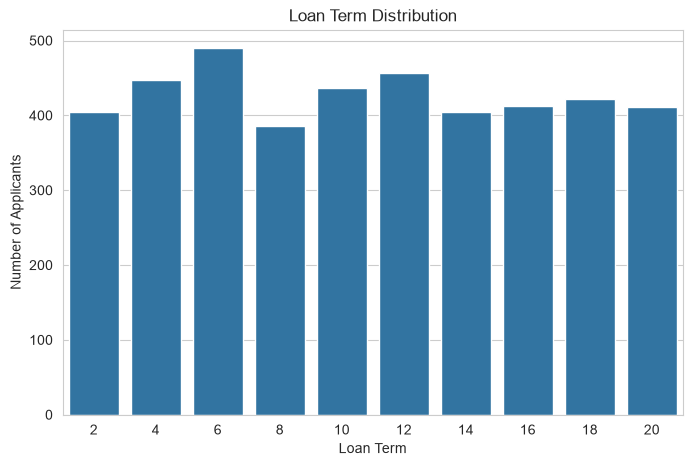

In [81]:

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="loan_term")

plt.ylabel("Number of Applicants")
plt.xlabel("Loan Term")
plt.title("Loan Term Distribution")

plt.show()

This count plot illustrates the number of applicants across the available loan terms. It can be observed that some loan duration are more popular than others. The 6-years plan is the most popular one with approximately 500 applicants followed by the 4, 10 and 12 years terms, each containing 450 applicants by estimate. The remaining terms have around 400 applicants each. Overall, the distribution appears relatively balanced, and none of the terms is dominating the dataset excessively, reducing the chances of machine learning models being biased.

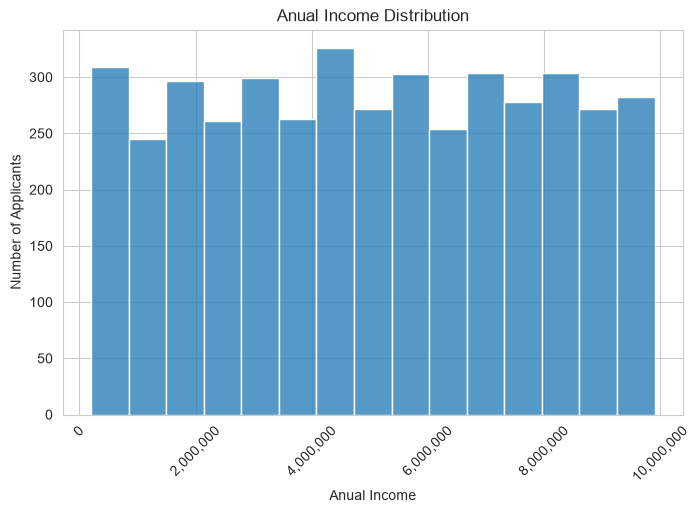

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.histplot(data=df, x="income_annum", bins=15)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.ylabel("Number of Applicants")
plt.xlabel("Anual Income")
plt.title("Annual Income Distribution")

plt.show()

This histogram shows the applicants distribution over different ranges of annual income. It can be interpreted number of customers in different income brackets is relatively consistent with no range dominating significantly. To illustrate, the highest range has 350 applicants and the lowest have 250 applicants with the rest of the income brackets having the number of applicants. Overall, the distribution appears to be balanced across all ranges, reducing the chances of machine learning models being biased towards it.

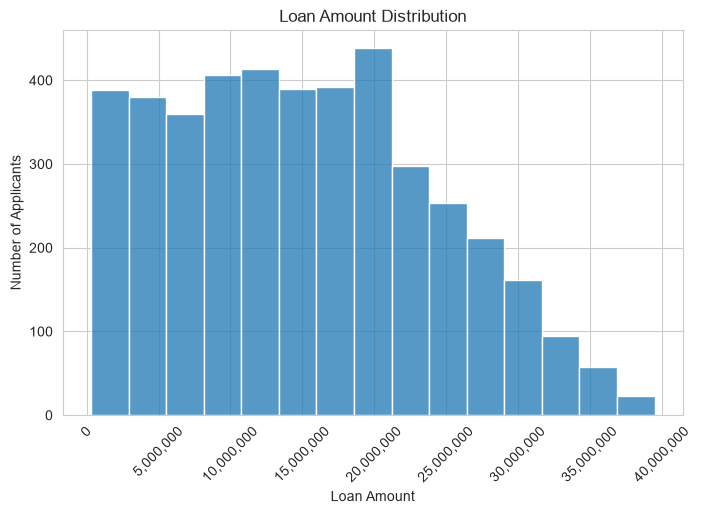

In [63]:
plt.figure(figsize=(8,5))

ax = sns.histplot(data=df, x="loan_amount", bins=15)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.ylabel("Number of Applicants")
plt.xlabel("Loan Amount")
plt.title("Loan Amount Distribution")

plt.show()

This histogram represents the distribution of applicants across different ranges of loan amounts. It can be noticed that there is a drop in number of applicants at 20 million loans, it drops from approximately 450 in the previous bracket to under 300 in the next bracket. All the ranges before that point maintain a high number of applicants ranging from 350 to 400 applicants. However, after that 20 million bracket all the applicant numbers in every range keep decreasing as the loan amount goes higher.  Overall, this could mean higher loan amounts are less frequent and they can be the minority in our dataset and as a result might not be optimal for predicting higher amount loans. 

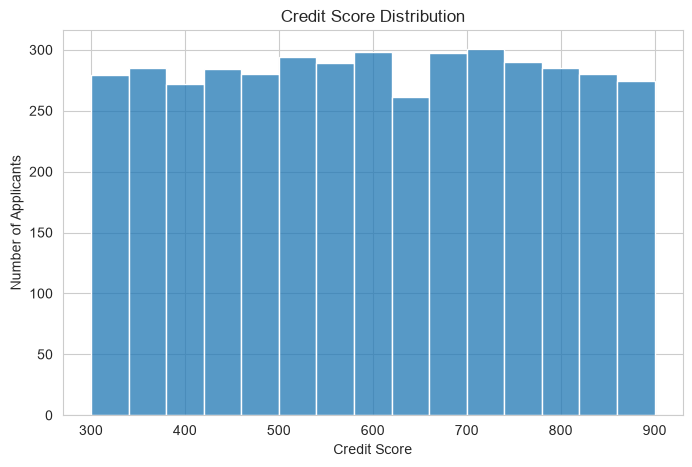

In [53]:

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="cibil_score", bins=15)

plt.ylabel("Number of Applicants")
plt.xlabel("Credit Score")
plt.title("Credit Score Distribution")

plt.show()

This histogram shows the population of applicants in different ranges of credit scores. From the chart it has been revealed that the distribution of users among all ranges is almost equal with 270 to 300 applicants in all ranges by an estimate with one exception of 630 to 690. This range has 240 applicants, which compared to rest of the range it is not of significance. Overall, the distribution of credit scores in our dataset is even as a result it will most probably not cause biases when passed to machine learning models. 

#### Relationships between features

In [65]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


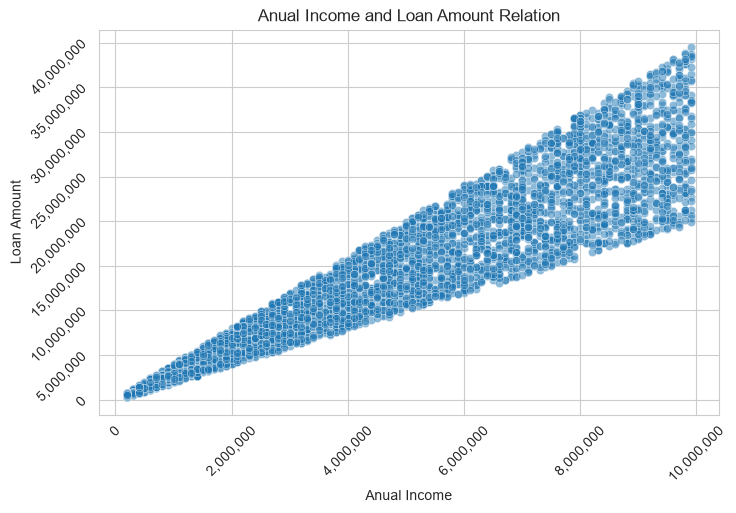

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.scatterplot(data=df, x="income_annum", y='loan_amount',alpha= 0.5)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(rotation=45)

plt.xlabel("Anual Income")
plt.ylabel("Loan Amount")

plt.title("Annual Income and Loan Amount Relation")



plt.show()

This scatter plot shows both the loan amount and the annual income of all applicants. It illustrates that all of the applicants are within a certain range of income and loan amount and there are no outliers. Also, lower income applicants have smaller loan amounts with smaller ranges. For example, at income of 4 million the loan amounts are between 5.5 million to 15 million. However, as income increases both the range and the minimum amount of loan also increases. To Illustrate, at 10 million income applicants can be find with loan amount from 20 to 40 million. 

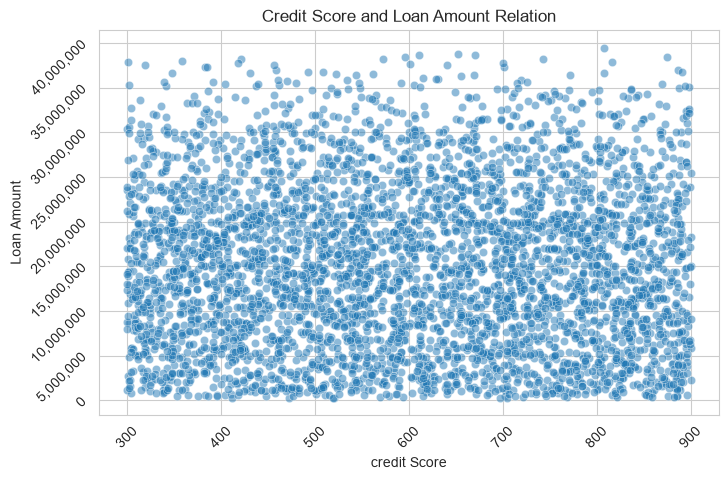

In [78]:
plt.figure(figsize=(8,5))

ax = sns.scatterplot(data=df, x="cibil_score", y='loan_amount', alpha= 0.5)

plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(rotation=45)

plt.xlabel("credit Score")
plt.ylabel("Loan Amount")

plt.title("Credit Score and Loan Amount Relation")



plt.show()